## DATA PREPARATION & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, brier_score_loss, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from ray import tune
from ray.tune.integration.pytorch_lightning import TuneReportCallback
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')

def load_local_data(dataset_choice="breast_cancer"):
    if dataset_choice == "breast_cancer":
        df = pd.read_csv("BreastCancer.csv")
        df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
        X = df.drop(columns=['diagnosis'])
        y = df['diagnosis'].astype('category').cat.codes
    elif dataset_choice == "heart_disease":
        df = pd.read_csv("HeartDisease.csv")
        X = df.drop(columns=['target'])
        y = df['target']
    else:
        raise ValueError("Wybierz 'breast_cancer' lub 'heart_disease'")
    
    X = X.fillna(X.median())
    return X, y

def iterative_vif_feature_selection(X, threshold=10.0):
    X_vif = X.copy()
    scaler = StandardScaler()
    
    while True:
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_vif.columns
        X_scaled = scaler.fit_transform(X_vif)
        
        vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
        max_vif = vif_data['VIF'].max()
        
        if max_vif > threshold:
            max_vif_feature = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
            X_vif = X_vif.drop(columns=[max_vif_feature])
        else:
            break
    return X_vif

def perform_eda(X_train, X_test, y_train, y_test):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    sns.countplot(x=y_train, ax=axes[0,0], palette="viridis")
    axes[0,0].set_title("Rozkład klas - Zbiór Treningowy")
    sns.countplot(x=y_test, ax=axes[0,1], palette="viridis")
    axes[0,1].set_title("Rozkład klas - Zbiór Testowy")
    
    feature_to_plot = X_train.columns[0]
    sns.boxplot(y=X_train[feature_to_plot], ax=axes[1,0], color='skyblue')
    axes[1,0].set_title(f"Boxplot {feature_to_plot} - Treningowy")
    sns.boxplot(y=X_test[feature_to_plot], ax=axes[1,1], color='lightgreen')
    axes[1,1].set_title(f"Boxplot {feature_to_plot} - Testowy")
    plt.tight_layout()
    plt.show()

    cols = X_train.columns[:15]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(X_train[cols].corr(), annot=False, cmap='coolwarm', ax=axes[0])
    axes[0].set_title("Korelacje cech - Trening")
    sns.heatmap(X_test[cols].corr(), annot=False, cmap='coolwarm', ax=axes[1])
    axes[1].set_title("Korelacje cech - Test")
    plt.tight_layout()
    plt.show()

## PYTORCH LIGHTNING DATA MODULE

In [2]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ClassificationDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64):
        super().__init__()
        self.X_train, self.y_train = X_train, y_train
        self.X_val, self.y_val = X_val, y_val
        self.X_test, self.y_test = X_test, y_test
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_dataset = CustomDataset(self.X_train, self.y_train)
        self.val_dataset = CustomDataset(self.X_val, self.y_val)
        self.test_dataset = CustomDataset(self.X_test, self.y_test)
        
        class_counts = np.bincount(self.y_train)
        class_weights = 1.0 / np.where(class_counts == 0, 1, class_counts)
        sample_weights = class_weights[self.y_train]
        self.sampler = WeightedRandomSampler(
            weights=sample_weights, 
            num_samples=len(sample_weights), 
            replacement=True
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, sampler=self.sampler)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

## PYTORCH LIGHTNING MODEL

In [3]:
class LitMLP(pl.LightningModule):
    def __init__(self, input_dim, num_classes, hidden_size=64, num_layers=2, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        layers = []
        in_dim = input_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size
        layers.append(nn.Linear(in_dim, num_classes))
        
        self.model = nn.Sequential(*layers)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log('test_loss', loss)
        self.log('test_acc', acc)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

## RAY TUNE HYPERPARAMETER TUNING

In [4]:
def train_tune(config, data_dict):
    X_train = data_dict['X_train']
    y_train = data_dict['y_train']
    X_val = data_dict['X_val']
    y_val = data_dict['y_val']
    
    dm = ClassificationDataModule(X_train, y_train, X_val, y_val, X_val, y_val, batch_size=64)
    model = LitMLP(
        input_dim=X_train.shape[1], 
        num_classes=data_dict['num_classes'], 
        hidden_size=config["hidden_size"], 
        num_layers=config["num_layers"], 
        lr=config["lr"]
    )
    
    trainer = Trainer(
        max_epochs=10, 
        callbacks=[TuneReportCallback({'val_loss': 'val_loss', 'val_acc': 'val_acc'}, on='validation_end')], 
        enable_progress_bar=False,
        logger=False,
        gradient_clip_val=1.0
    )
    trainer.fit(model, datamodule=dm)

## XAI, CALIBRATION & EXTRA PLOTS

In [5]:
def plot_training_metrics(metrics_path):
    if os.path.exists(metrics_path):
        metrics = pd.read_csv(metrics_path)
        
        train_loss = metrics['train_loss'].dropna()
        val_loss = metrics['val_loss'].dropna()
        train_acc = metrics['train_acc'].dropna()
        val_acc = metrics['val_acc'].dropna()
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(train_loss.values, label='Train Loss', color='blue')
        axes[0].plot(val_loss.values, label='Validation Loss', color='red')
        axes[0].set_title("Krzywa funkcji straty (Loss)")
        axes[0].set_xlabel("Epoki")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        
        axes[1].plot(train_acc.values, label='Train Accuracy', color='blue')
        axes[1].plot(val_acc.values, label='Validation Accuracy', color='red')
        axes[1].set_title("Krzywa dokładności (Accuracy)")
        axes[1].set_xlabel("Epoki")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()

def evaluate_and_plot(model, X_train, y_train, X_test, y_test, num_classes):
    model.eval()
    
    with torch.no_grad():
        logits_train = model(torch.tensor(X_train.values, dtype=torch.float32))
        probs_train = torch.softmax(logits_train, dim=1).numpy()
        preds_train = np.argmax(probs_train, axis=1)

        logits_test = model(torch.tensor(X_test.values, dtype=torch.float32))
        probs_test = torch.softmax(logits_test, dim=1).numpy()
        preds_test = np.argmax(probs_test, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cm_train = confusion_matrix(y_train, preds_train)
    ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Macierz Konfuzji - Trening")
    
    cm_test = confusion_matrix(y_test, preds_test)
    ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Macierz Konfuzji - Test")
    plt.tight_layout()
    plt.show()

    if num_classes == 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        fpr_tr, tpr_tr, _ = roc_curve(y_train, probs_train[:, 1])
        axes[0].plot(fpr_tr, tpr_tr, color='blue', lw=2, label=f'ROC AUC = {auc(fpr_tr, tpr_tr):.2f}')
        axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
        axes[0].set_title("Krzywa ROC - Trening")
        axes[0].legend(loc="lower right")
        
        fpr_te, tpr_te, _ = roc_curve(y_test, probs_test[:, 1])
        axes[1].plot(fpr_te, tpr_te, color='red', lw=2, label=f'ROC AUC = {auc(fpr_te, tpr_te):.2f}')
        axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
        axes[1].set_title("Krzywa ROC - Test")
        axes[1].legend(loc="lower right")
        plt.tight_layout()
        plt.show()

    prob_true, prob_pred = calibration_curve(y_test == 0, probs_test[:, 0], n_bins=10)
    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker='o', label='Model')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Idealnie skalibrowany')
    plt.title("Krzywa Kalibracji (Klasa 0)")
    plt.legend()
    plt.show()

    max_probs = np.max(probs_test, axis=1)
    most_certain_idx = np.argmax(max_probs)
    least_certain_idx = np.argmin(max_probs)
    
    print(f"\nNajbardziej pewny przypadek (Index {most_certain_idx}): Prawdopodobieństwo = {max_probs[most_certain_idx]:.4f}")
    print(f"Najmniej pewny przypadek (Index {least_certain_idx}): Prawdopodobieństwo = {max_probs[least_certain_idx]:.4f}")

    def proba_predict(X_np):
        with torch.no_grad():
            t = torch.tensor(X_np, dtype=torch.float32)
            return torch.softmax(model(t), dim=1).numpy()
            
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=X_train.columns.tolist(),
        class_names=[str(c) for c in range(num_classes)],
        mode='classification'
    )
    
    exp_certain = explainer.explain_instance(X_test.values[most_certain_idx], proba_predict, num_features=5)
    fig_cert = exp_certain.as_pyplot_figure()
    fig_cert.suptitle("LIME: Wyjaśnienie najbardziej pewnego przypadku")
    plt.tight_layout()
    plt.show()
    
    exp_uncertain = explainer.explain_instance(X_test.values[least_certain_idx], proba_predict, num_features=5)
    fig_uncert = exp_uncertain.as_pyplot_figure()
    fig_uncert.suptitle("LIME: Wyjaśnienie najmniej pewnego przypadku")
    plt.tight_layout()
    plt.show()

## MAIN EXECUTION

Ładowanie danych: heart_disease...


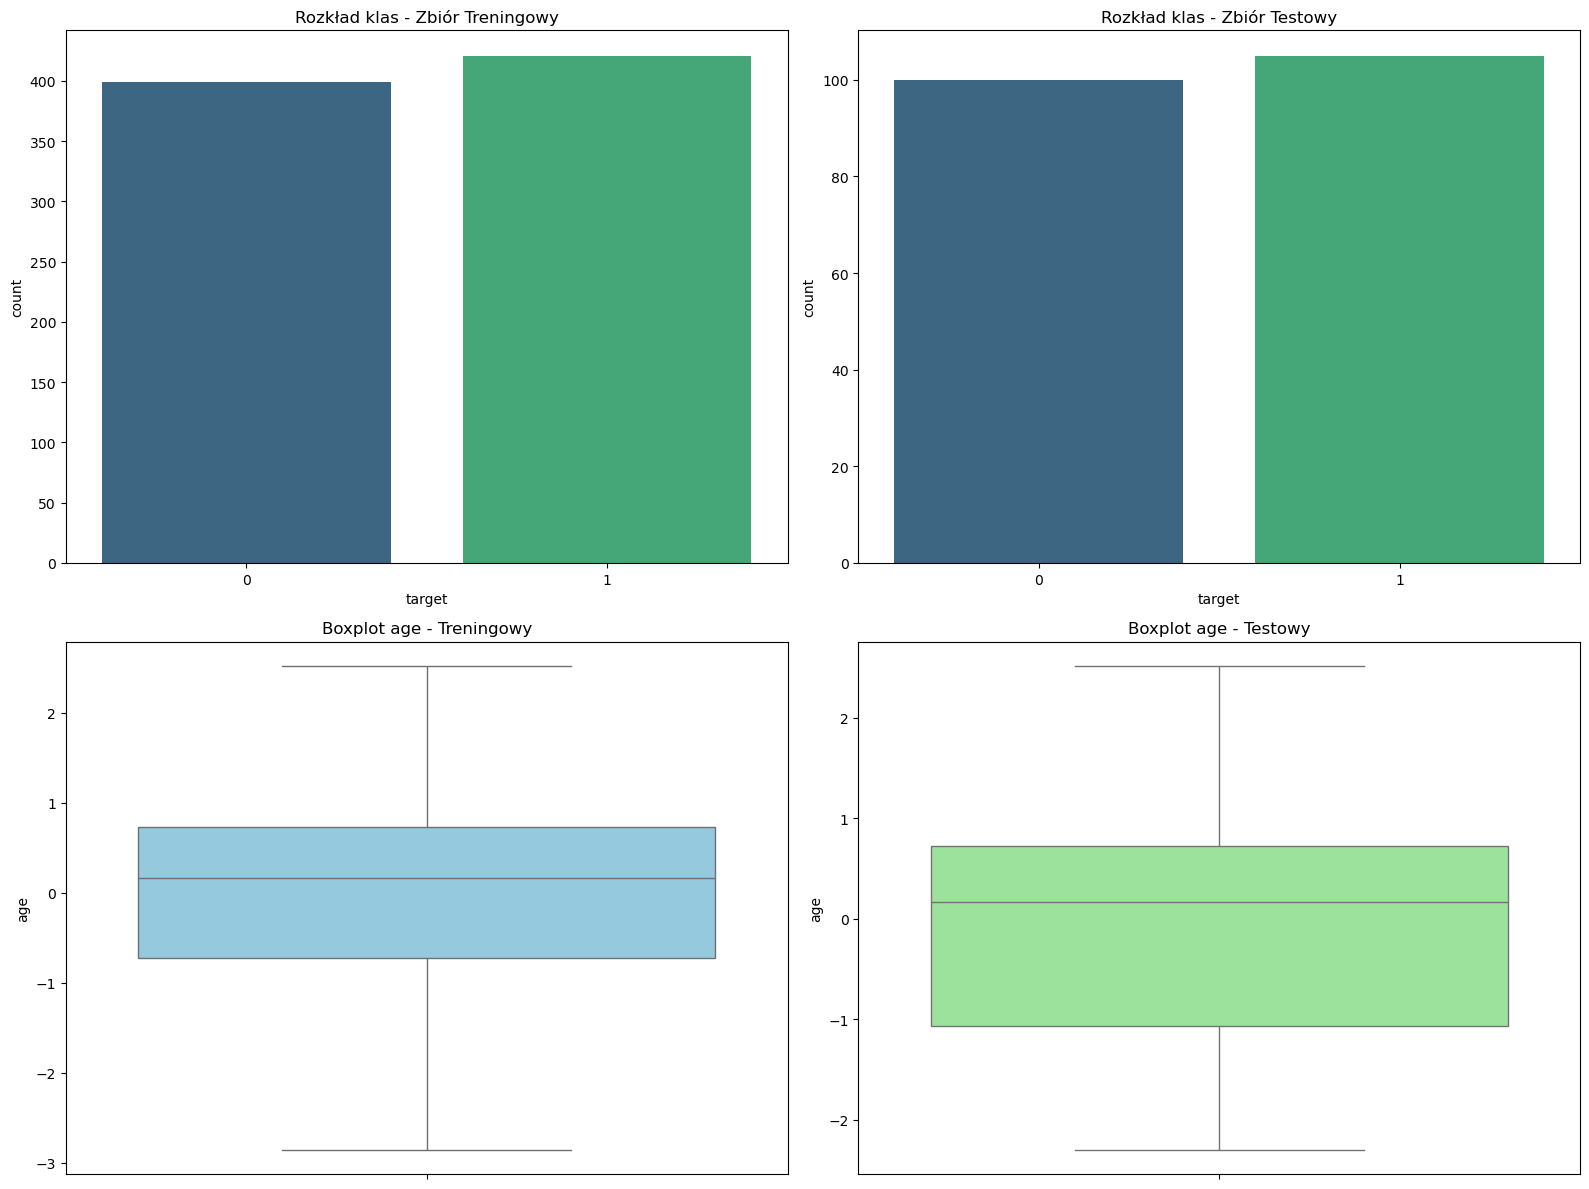

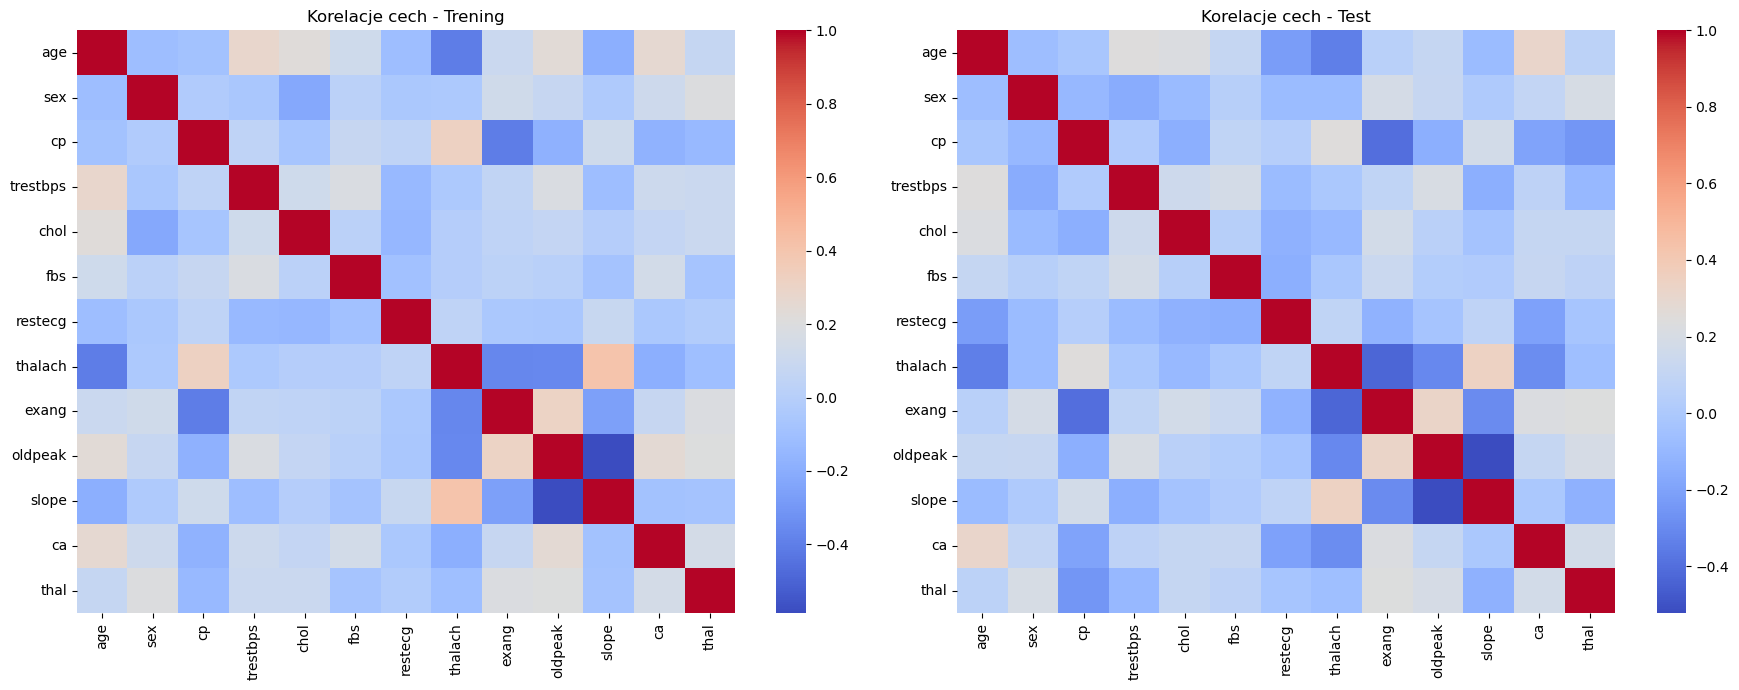

2026-06-30 18:05:02,969	INFO worker.py:2012 -- Started a local Ray instance.
2026-06-30 18:05:04,204	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2026-06-30 18:05:04,209	INFO tune.py:615 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
2026-06-30 18:05:04,266	INFO tensorboardx.py:43 -- pip install "ray[tune]" to see TensorBoard files.
2026-06-30 18:05:04,268	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


(train_tune pid=19459) /home/martyna/anaconda3/lib/python3.13/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(train_tune pid=19459) GPU available: False, used: False
(train_tune pid=19459) TPU available: False, using: 0 TPU cores
(train_tune pid=19459) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(train_tune pid=19459) 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


(train_tune pid=19459) ┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(train_tune pid=19459) ┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
(train_tune pid=19459) ┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(train_tune pid=19459) │ 0 │ model     │ Sequential       │  1.7 K │ train │     0 │
(train_tune pid=19459) │ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
(train_tune pid=19459) └───┴───────────┴──────────────────┴────────┴───────┴───────┘
(train_tune pid=19459) Trainable params: 1.7 K                                                         
(train_tune pid=19459) Non-trainable params: 0                                                         
(train_tune pid=19459) Total params: 1.7 K                                                             
(train_tune pid=19459) Total estimated model params size (MB): 0.007                                   
(train_tune pid=19459) Modules in train mode: 9                           

(train_tune pid=19459) /home/martyna/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(train_tune pid=19459) /home/martyna/anaconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
(train_tune pid=19459) /home/martyna/anaconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Trial name,val_acc,val_loss
train_tune_74c03_00000,0.865854,0.32426
train_tune_74c03_00001,0.908537,0.264847
train_tune_74c03_00002,0.963415,0.142237
train_tune_74c03_00003,0.957317,0.105123
train_tune_74c03_00004,0.792683,0.42439


...

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9365853667259216     │
│         test_loss         │     0.141219362616539     │
└───────────────────────────┴───────────────────────────┘


Ładowanie najlepszego modelu z: /home/martyna/Desktop/Zaliczenie3/checkpoints/best_model-v13.ckpt

Ocena na zbiorze testowym...


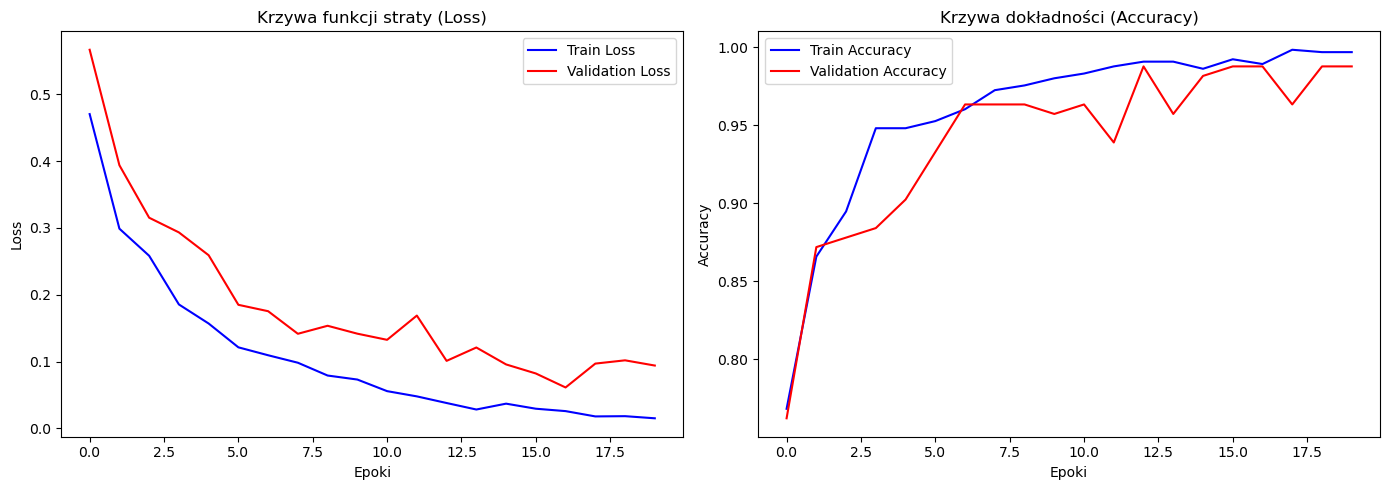

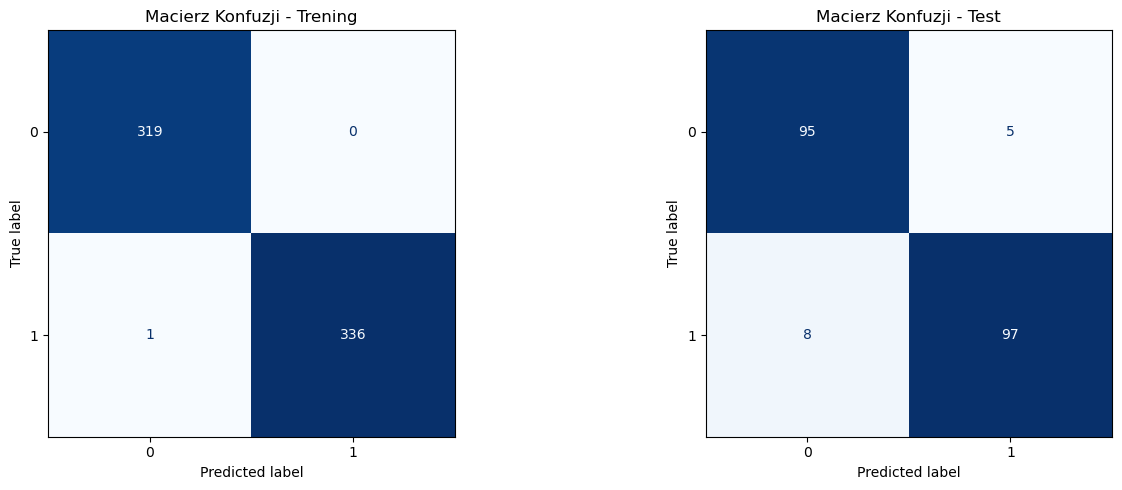

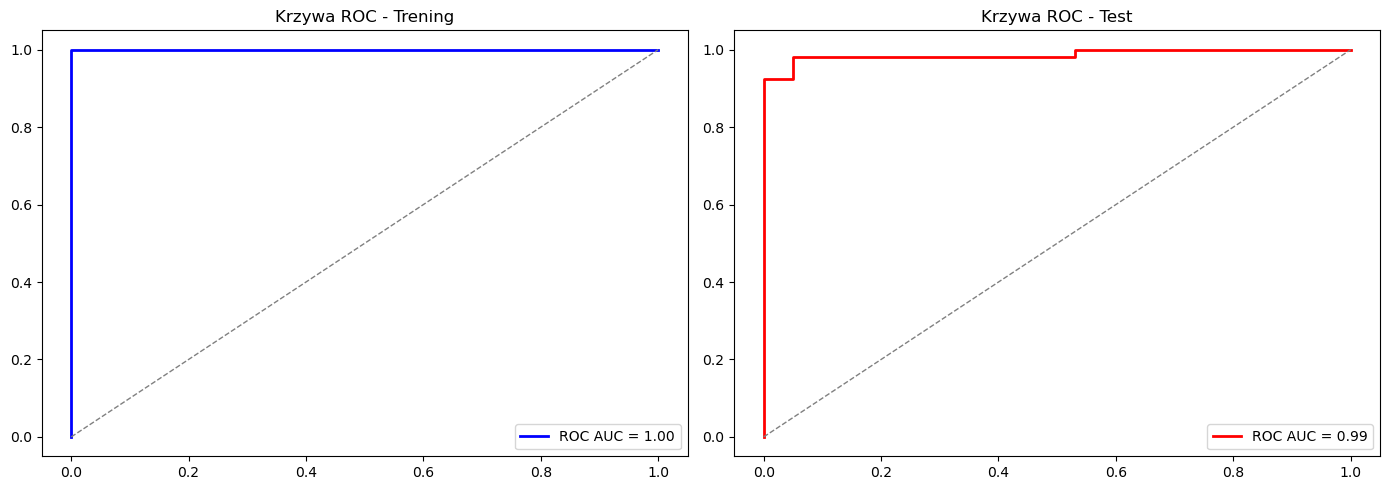

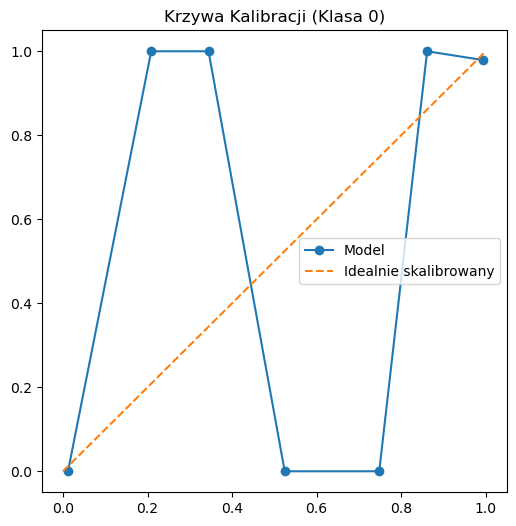


Najbardziej pewny przypadek (Index 65): Prawdopodobieństwo = 1.0000
Najmniej pewny przypadek (Index 36): Prawdopodobieństwo = 0.5245


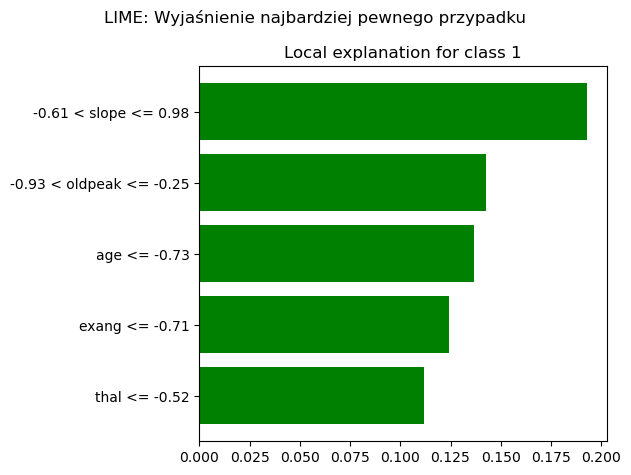

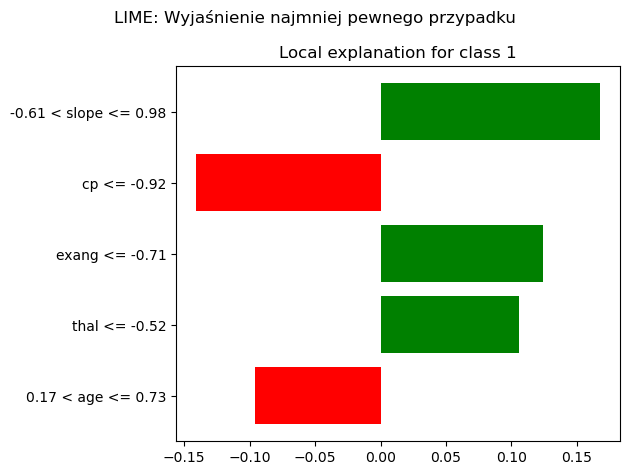

In [6]:
DATASET = 'heart_disease'

print(f"Ładowanie danych: {DATASET}...")
X, y = load_local_data(DATASET) 

X = iterative_vif_feature_selection(X, threshold=10.0)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

scaler = StandardScaler()
X_train_val = pd.DataFrame(scaler.fit_transform(X_train_val), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

y_train_val = y_train_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

perform_eda(X_train_val, X_test, y_train_val, y_test)

input_dim = X_train_val.shape[1]
num_classes = len(np.unique(y))

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, stratify=y_train_val)

data_dict = {
    'X_train': X_train, 'y_train': y_train, 
    'X_val': X_val, 'y_val': y_val, 
    'num_classes': num_classes
}

analysis = tune.run(
    tune.with_parameters(train_tune, data_dict=data_dict),
    config={
        'hidden_size': tune.choice([32, 64, 128]),
        'num_layers': tune.choice([1, 2, 3]),
        'lr': tune.loguniform(1e-4, 1e-2)
    },
    metric='val_loss',
    mode='min',
    num_samples=5
)

best_config = analysis.get_best_config(metric='val_loss', mode='min')
print("Najlepsze hiperparametry:", best_config)

dm = ClassificationDataModule(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64)
model = LitMLP(input_dim, num_classes, **best_config)

checkpoint_callback = ModelCheckpoint(
    dirpath='./checkpoints',
    filename='best_model',
    save_top_k=1,
    monitor='val_loss',
    mode='min'
)

csv_logger = CSVLogger("logs", name="my_model")

trainer = Trainer(
    max_epochs=20,
    callbacks=[checkpoint_callback, EarlyStopping(monitor='val_loss', patience=5)],
    logger=csv_logger,
    gradient_clip_val=1.0
)
trainer.fit(model, datamodule=dm)

print(f"\nŁadowanie najlepszego modelu z: {checkpoint_callback.best_model_path}")
best_model = LitMLP.load_from_checkpoint(checkpoint_callback.best_model_path)

print("\nOcena na zbiorze testowym...")
trainer.test(best_model, datamodule=dm)

metrics_path = f"{csv_logger.log_dir}/metrics.csv"
plot_training_metrics(metrics_path)

evaluate_and_plot(best_model, X_train, y_train, X_test, y_test, num_classes)